<h2 style="text-align: center;">НАЦИОНАЛЬНЫЙ ИССЛЕДОВАТЕЛЬСКИЙ УНИВЕРСИТЕТ 
<br/>МОСКОВСКИЙ ЭНЕРГЕТИЧЕСКИЙ ИНСТИТУТ</h2>
</br>
<h3 style="text-align: center;">Кафедра Паровых и Газовых Турбин</h3>

</br>
</br>
</br>
</br>
</br>

<h1 style="text-align: center;">Курсовая работа по курсу:</h1>
<h1 style="text-align: center;">«Паровые и газовые турбины»</h1>

</br>
<h1 style="text-align: center;">Вариант 9</h2>
</br>
</br>
</br>
</br>

<h5 style="text-align: right;">Студент: Смирнов Сергей Артёмович</h5>
<h5 style="text-align: right;">Группа: ФПэ-01-22</h5>

</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>

<h5 style="text-align: center;">Москва 2025</h5>

## Вариант №9

### $\space$ Дано:
* $P_0 = 23.4 \space МПа $ - Давление перед турбиной
* $t_0 = 545 ^\circ C$ -  Температура перед турбиной
* $P_{пп} = 3.3 \space МПа$ -  Давление промперегрева
* $t_{пп} = 545 ^\circ C$ -  Температура промперегрева
* $P_{к} = 5 \space кПа$ -  Давление в конденсаторе
* $t_{п.в.} = 263^\circ C$ -  Температура питательной воды

* $N_{э} = 320 \space МВт$ -  Электрическая мощность
* z = 9 -  Количество перегревателей

In [72]:
from mass_flow_class import mass_flow_class as mfc
from control_stage import control_stage as cst
from steam import Steam as sgas
import numpy as np

In [73]:
MPa = 10 ** 6
kPa = 10 ** 3
unit = 1 / MPa
to_kelvin = lambda x: x + 273.15 if x else None

In [74]:
p0 = 23.4 * MPa
my_class = sgas(name = "Пар", R = 461, c_p =287.05)

In [75]:
A = mfc(my_class,
        p0 = 23.4 * MPa ,
                   t0 = 545 ,
                   p_middle = 3.3 * MPa ,
                   t_middle = 545 ,
                   pk = 5 * kPa, 
                   t_feed_water = 263,
                   p_feed_water = 1.35 * p0*unit,

                   electrical_power = 320*10**6,
                   internal_efficiency = 0.85,
                   mechanical_efficiency = 0.995,
                   generator_efficiency = 0.99,
                   alpha = 0.83)
inlet_mass_flow = A.inlet_mass_flow
condenser_mass_flow = A.condenser_mass_flow
print("Расход на входе в турбину: ",round(inlet_mass_flow), "кг /с")
print("Расход на входе в конденсатор: ",round(condenser_mass_flow), "кг/с")

Расход на входе в турбину:  255 кг /с
Расход на входе в конденсатор:  174 кг/с


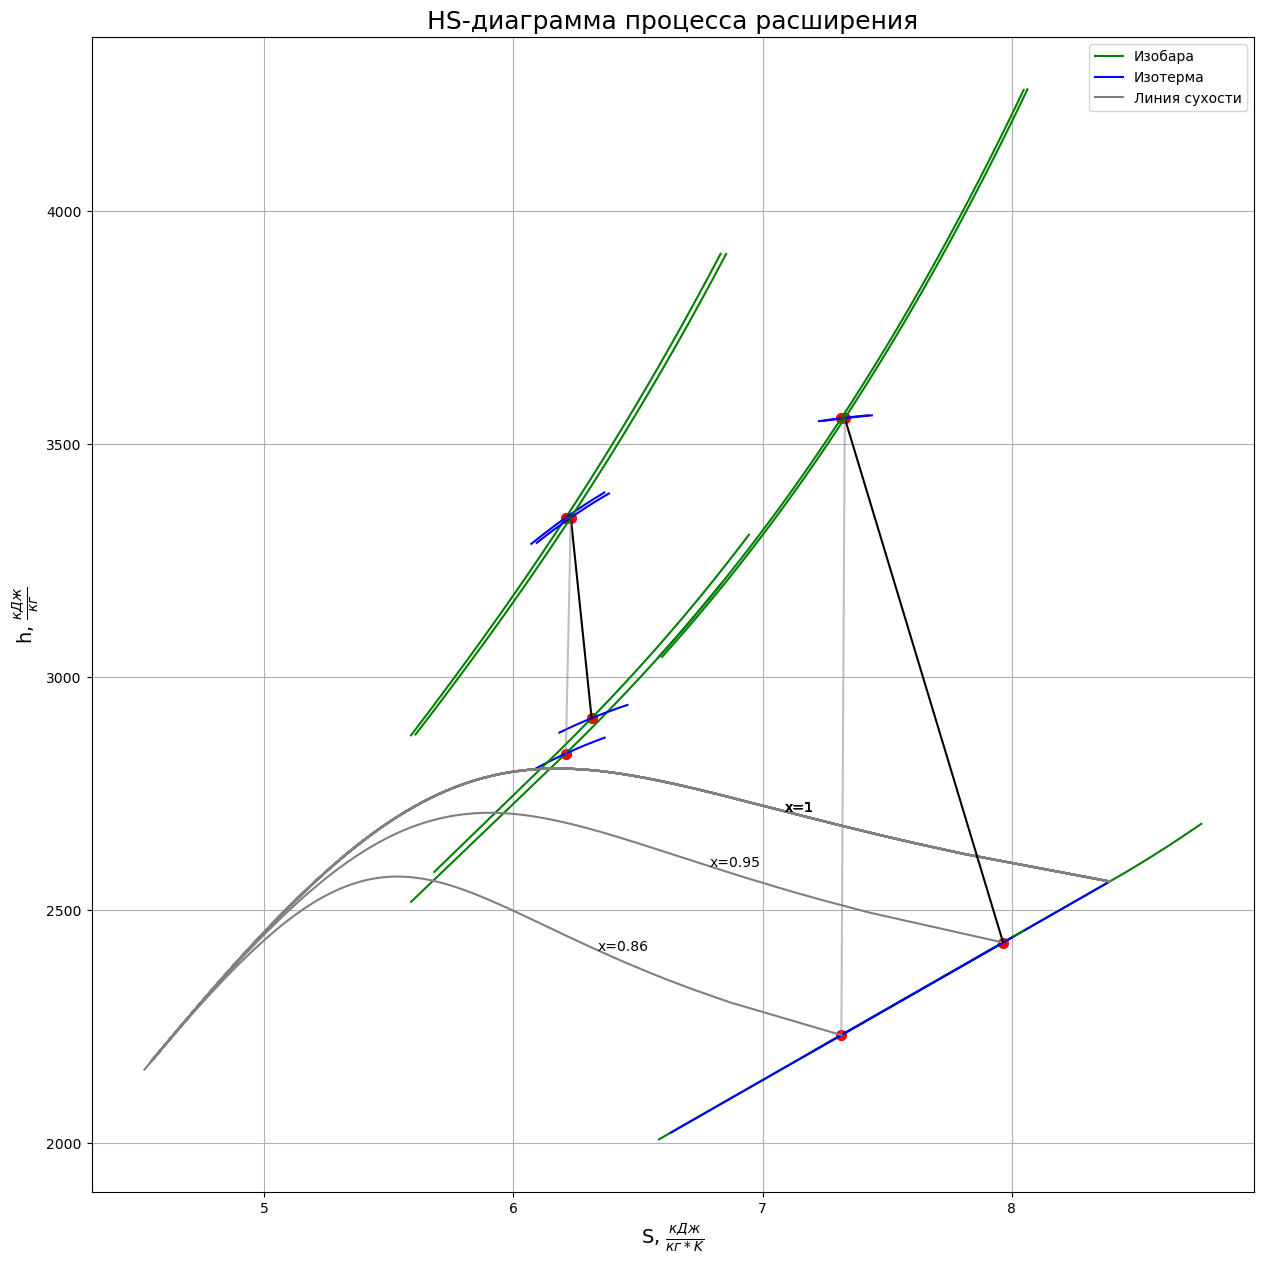

In [76]:
A.all_hs_plot

# Задание 2

Проведение расчёта регулирующей ступени и определние зависимости $\eta_{ол}$ от $U/c_f$. Диапазон варирьуемого параметра - диаметра - задан; обоснованно выбрать вариант исполнения регулирующей ступени для проектирования ЦВД в рамках заданного диапазона

Выберем в качестве сопловой лопатки *С-90-15А*, в качестве рабочей: *Р-26-17А*
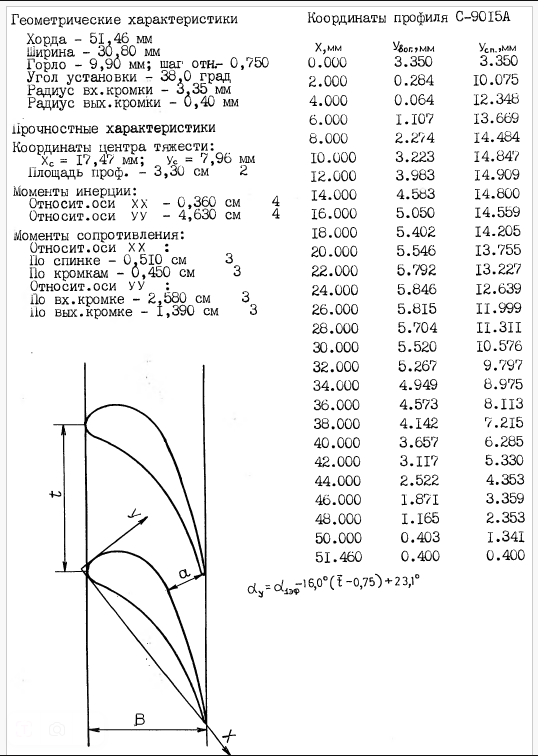
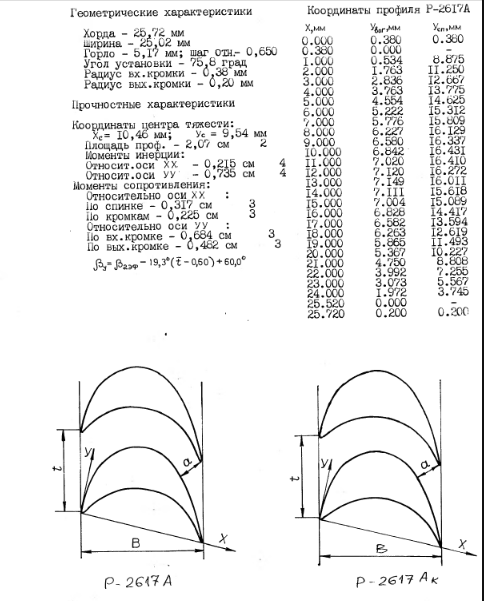

In [77]:
import math
H_0 = 100
B  = cst(my_class, A, H_0, n= 60, d =1.1, b_1 = 51.5/1000, t_1opt = 0.8,
                   alpha_1e = 14, b_2= 0.070911,t_2opt = 0.8)

d_r = np.arange(0.9,1.1,0.02) 

_eff_ol_energy = []
_eff_ol_angle = []
_eff_oi = []
_u_cf = []
n = 60
b_1 = 51.5 / 1000
t_1opt = 0.8
alpha_1e = 14
b_2 = 0.070911
t_2opt = 0.8

_eff_ol_energy = []
_eff_ol_angle = []
_eff_oi = []
_u_cf = []
for i in range(len(d_r)):
    B  = cst(my_class, A, H_0, d_r[i], n, b_1,t_1opt, alpha_1e, b_2, t_2opt)
    _eff_ol_energy.append(B.eff1[0])
    _eff_ol_angle.append(B.eff1[1])
    _eff_oi.append(B.eff1[2])
    _u_cf.append((B.eff1[3]))
    
print(B.M_1t)

0.6831001373103516


M_1t < 0.85, что соответствует заданному профилю

<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:20: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:23: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:20: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:23: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Vait_\AppData\Local\Temp\ipykernel_20632\703312255.py:4: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel(f"$\eta$, %")
C:\Users\Vait_\AppData\Local\Temp\ipykernel_20632\703

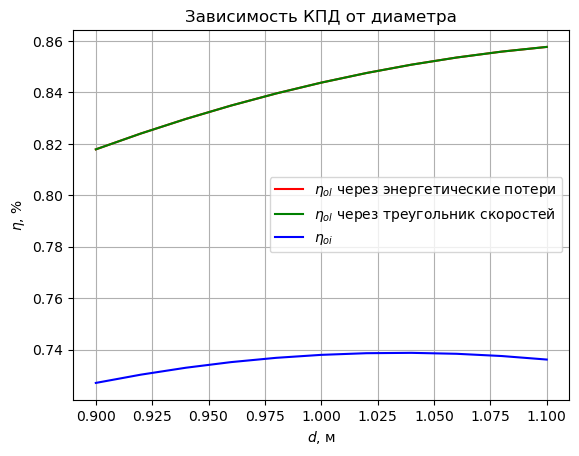

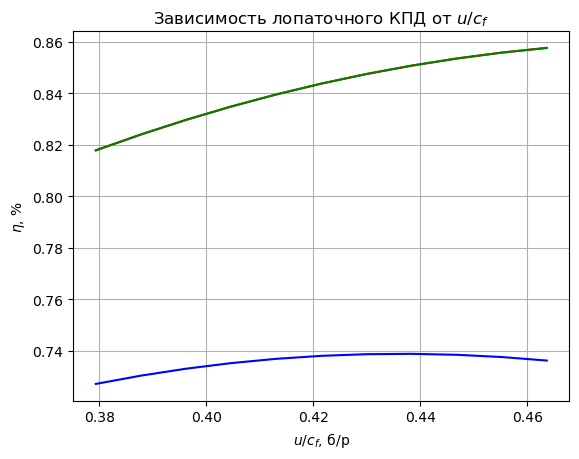

In [78]:
import matplotlib.pyplot as plt
plt.title("Зависимость КПД от диаметра") 
plt.xlabel(f"$d$, м") 
plt.ylabel(f"$\eta$, %")     
plt.plot(d_r,_eff_ol_energy , color ="red", label = "$\eta_{ol}$ через энергетические потери")
plt.plot(d_r,_eff_ol_angle, color ="green",label = "$\eta_{ol}$ через треугольник скоростей")


max_eff = np.argmax(_eff_ol_energy)

d_opt = d_r[max_eff]

plt.plot(d_r,_eff_oi, color ="blue", label = "$\eta_{oi}$")
plt.grid(True)
plt.legend()
plt.show()

plt.title("Зависимость лопаточного КПД от $u/c_f$") 
plt.xlabel(f"$u/c_f$, б/р") 
plt.ylabel(f"$\eta$, %")     
plt.plot(_u_cf,_eff_ol_energy , color ="red", label = "$\eta_{ol}$ через энергетические потери")
plt.plot(_u_cf,_eff_ol_angle, color ="green",label = "$\eta_{ol}$ через треугольник скоростей")
plt.plot(_u_cf,_eff_oi, color ="blue", label = "$\eta_{oi}$")
plt.grid(True)
plt.show()

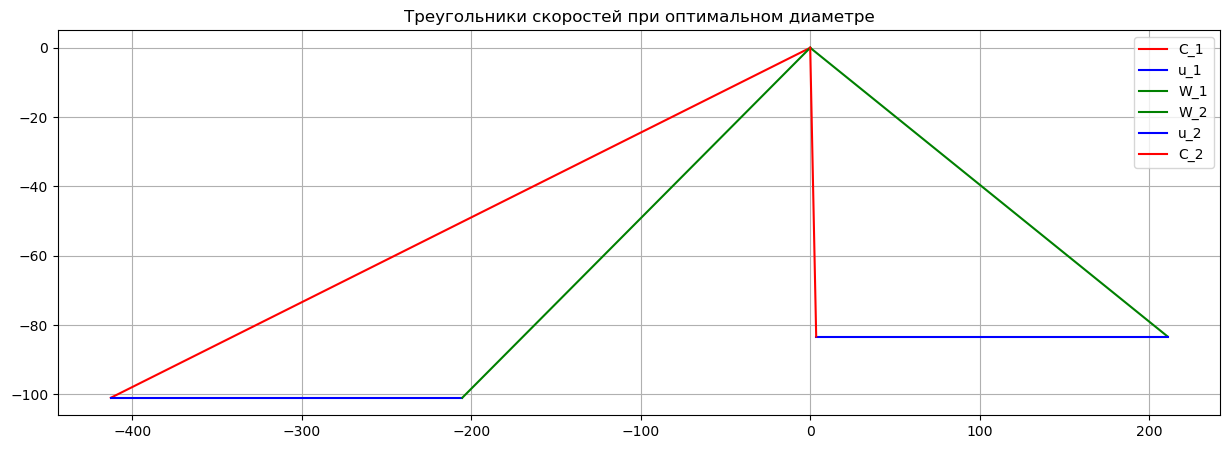

In [79]:
B  = cst(my_class, A, H_0, d_opt , n, b_1,t_1opt, alpha_1e, b_2, t_2opt)
velocity_df, loss_df, thermodynamic_df = B.create_results_tables
B.both_plot_velocity_triangles

In [80]:
loss_df

,"Потери, %"
Тип потерь,
В сопловой решетке,2.267
В рабочей решетке,7.966
Энергия выходной скорости,4.004
Потери от утечек через уплотнение,4.293
Потери от трения диска,0.764
Потери от парциальности,7.088


In [81]:
thermodynamic_df

,"Давление (P), МПа","Температура (T), K","Энтальпия (h), кДж/кг","Энтропия (s), кДж/(кг·K)"
Состояние,,,,
Параметры перед ступенью,22.230,540.605,3342.009,6.231
Теоретические параметры за сопловой решеткой,16.469,486.408,3249.509,6.231
Фактические параметры за сопловой решеткой,16.469,487.141,3251.776,6.234
Теоретические параметры за ступенью,16.060,485.332,3252.241,6.244
Фактические параметры за ступенью,16.060,485.332,3252.241,6.244


In [82]:
velocity_df

,"Абсолютная скорость (с), м/с","Абсолютный угол (α), °","Относительная скорость (w), м/с","Относительный угол (β), °"
Локация,,,,
За сопловой решеткой,[424.814],13.756,228.792,26.201
За рабочей решеткой,89.493,89.362,226.748,21.563


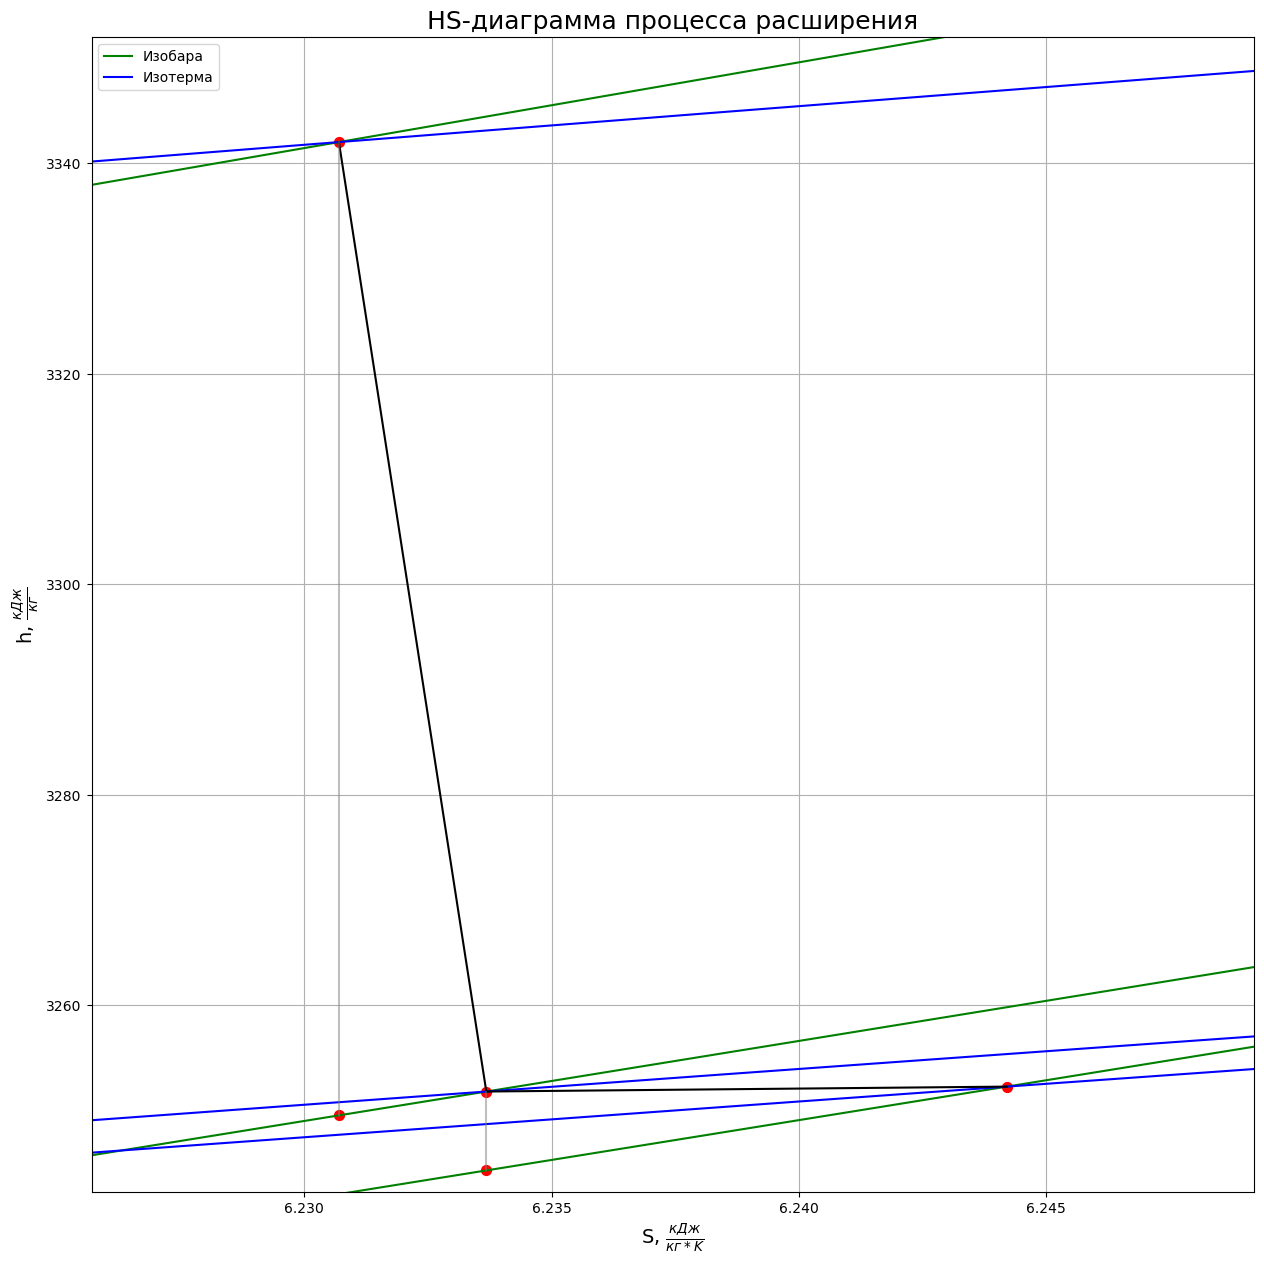

In [83]:
B.hs1

In [84]:
B  = cst(my_class, A, H_0, d_opt , n, b_1,t_1opt, alpha_1e, b_2, t_2opt)
sigma_isg, sigma_rast, b_2, l_2, z_2 = B.stress(0.153,51.5/1000,0.45 /10**6)
print("Прочностные и геометрические параметры:")
print(f"Напряжение на изгиб: {sigma_isg:.2f} МПа")#, , sigma_rast, b_2, l_2, z_2 
print(f"Напряжение на растяжение: {sigma_rast:.2f} МПа")
print(f"Хорда рабочей лопатки: {b_2*10**3:.2f} мм")
print(f"Высота рабочей лопатки: {l_2*10**3:.2f} мм")
print(f"Количество рабочих лопаток: {z_2}")


Прочностные и геометрические параметры:
Напряжение на изгиб: 3.37 МПа
Напряжение на растяжение: 2.07 МПа
Хорда рабочей лопатки: 29.12 мм
Высота рабочей лопатки: 26.50 мм
Количество рабочих лопаток: 61


## Задание 3 по ступеням

In [85]:
from mass_flow_class import mass_flow_class as mfc
from control_stage import control_stage as cst
from steam import Steam as sgas
import numpy as np

In [86]:
MPa = 10 ** 6
kPa = 10 ** 3
unit = 1 / MPa
to_kelvin = lambda x: x + 273.15 if x else None
d_opt = 1.1
H_0 = 100
n = 60
b_1 = 51.5/1000
b_2 = 0.153
t_1opt = 0.8
alpha_1e = 14
t_2opt = 0.8

In [87]:
p0 = 25 * MPa
my_class = sgas(name = "Пар", R = 461, c_p =287.05)
A = mfc(my_class,
                    p0 = 23.4 * MPa,
                    t0 = 545,
                    p_middle = 3.3 * MPa ,
                    t_middle = 545 ,
                    pk = 5 * kPa, 
                    t_feed_water = 263,
                    p_feed_water = 1.35 * p0*unit,

                    electrical_power = 320*10**6,
                    internal_efficiency = 0.85,
                    mechanical_efficiency = 0.995,
                    generator_efficiency = 0.99,
                    alpha = 0.83)
B  = cst(my_class, A, H_0, d_opt , n, b_1,t_1opt, alpha_1e, b_2, t_2opt)

Ошибка определения веерности:  51.214905497071996 %'
Ошибка определения веерности:  4.325492649678731 %'
Ошибка определения веерности:  0.392948848917359 %'
Новое число ступеней:  8.649500861260622


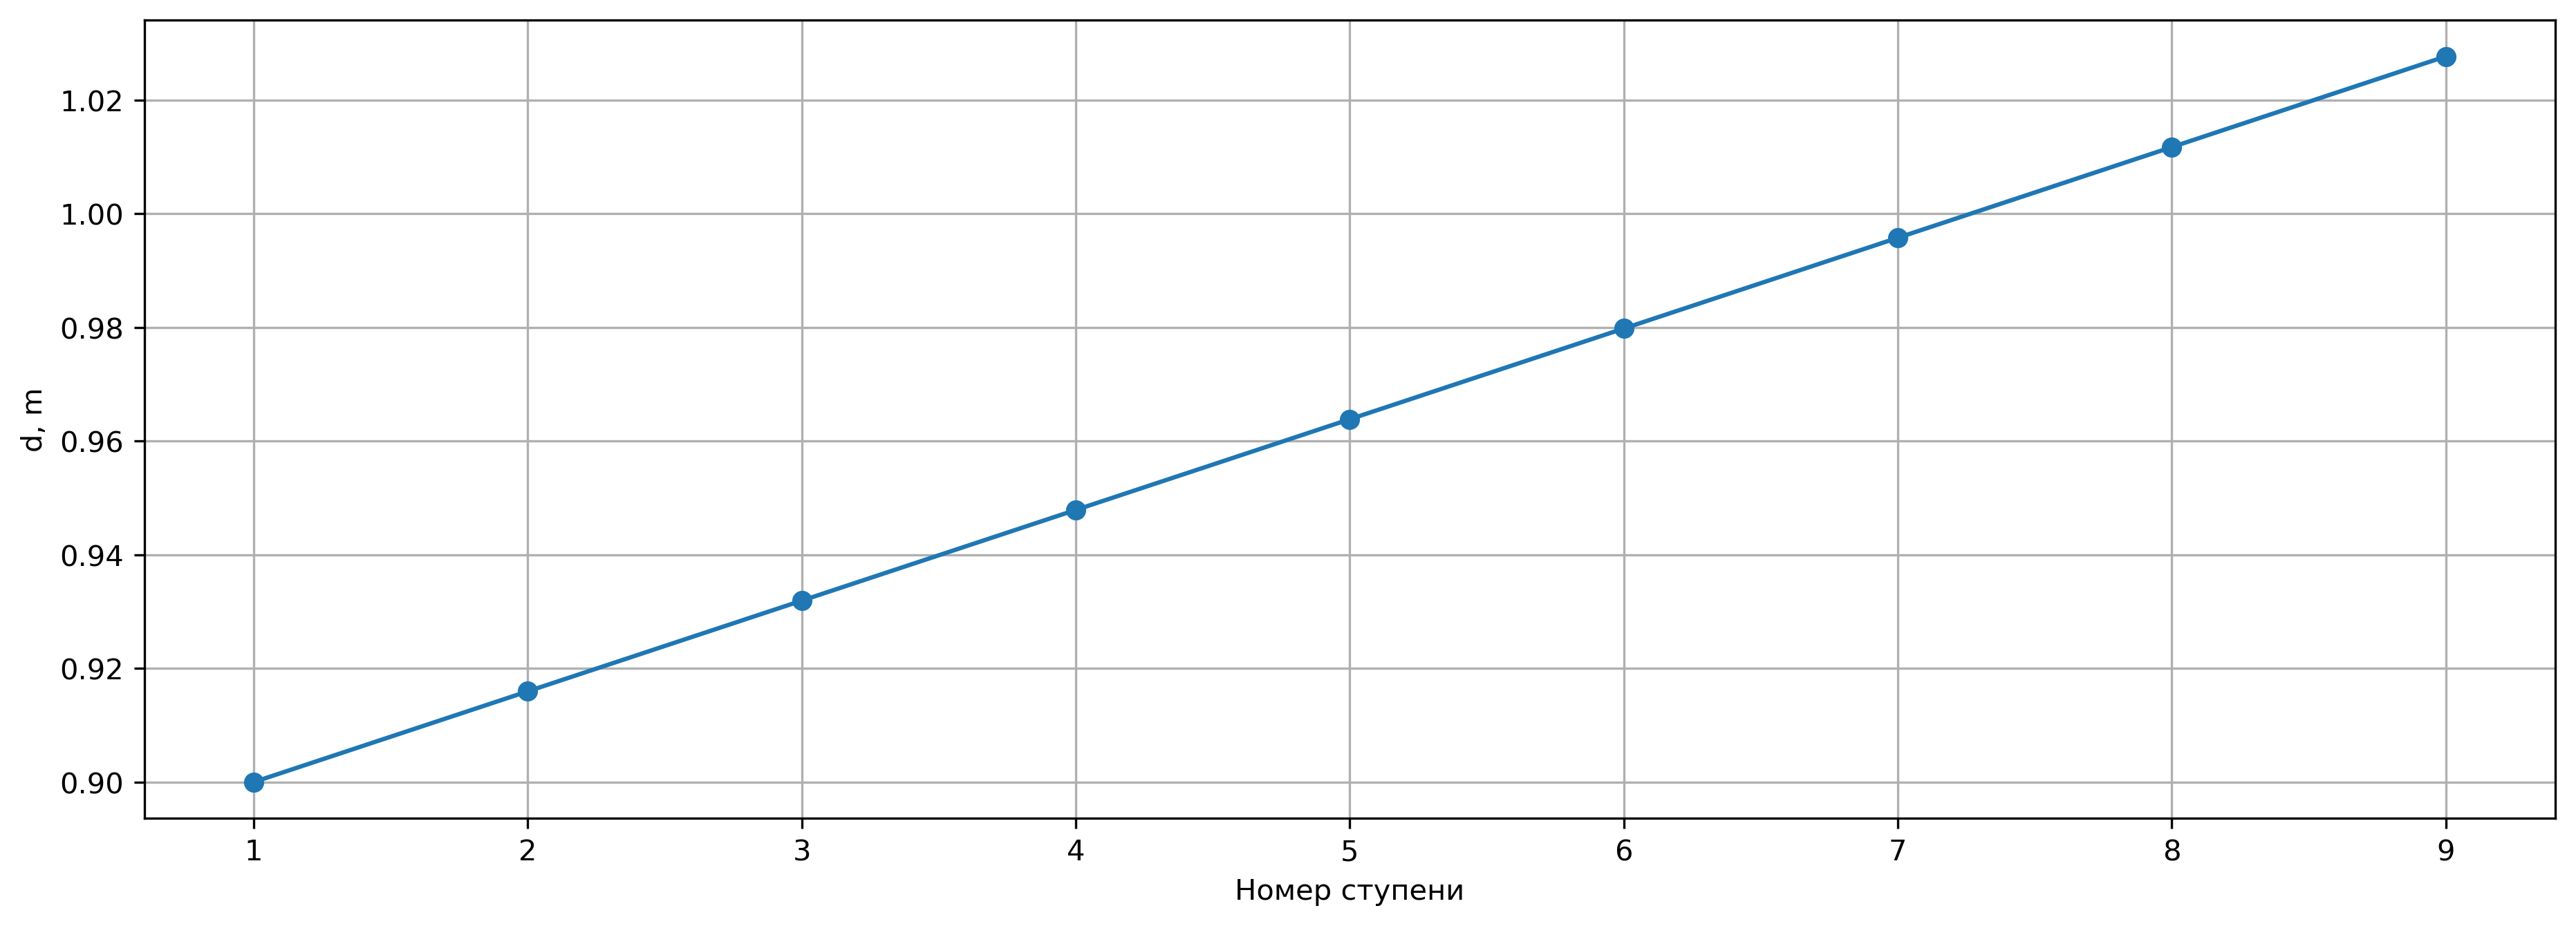

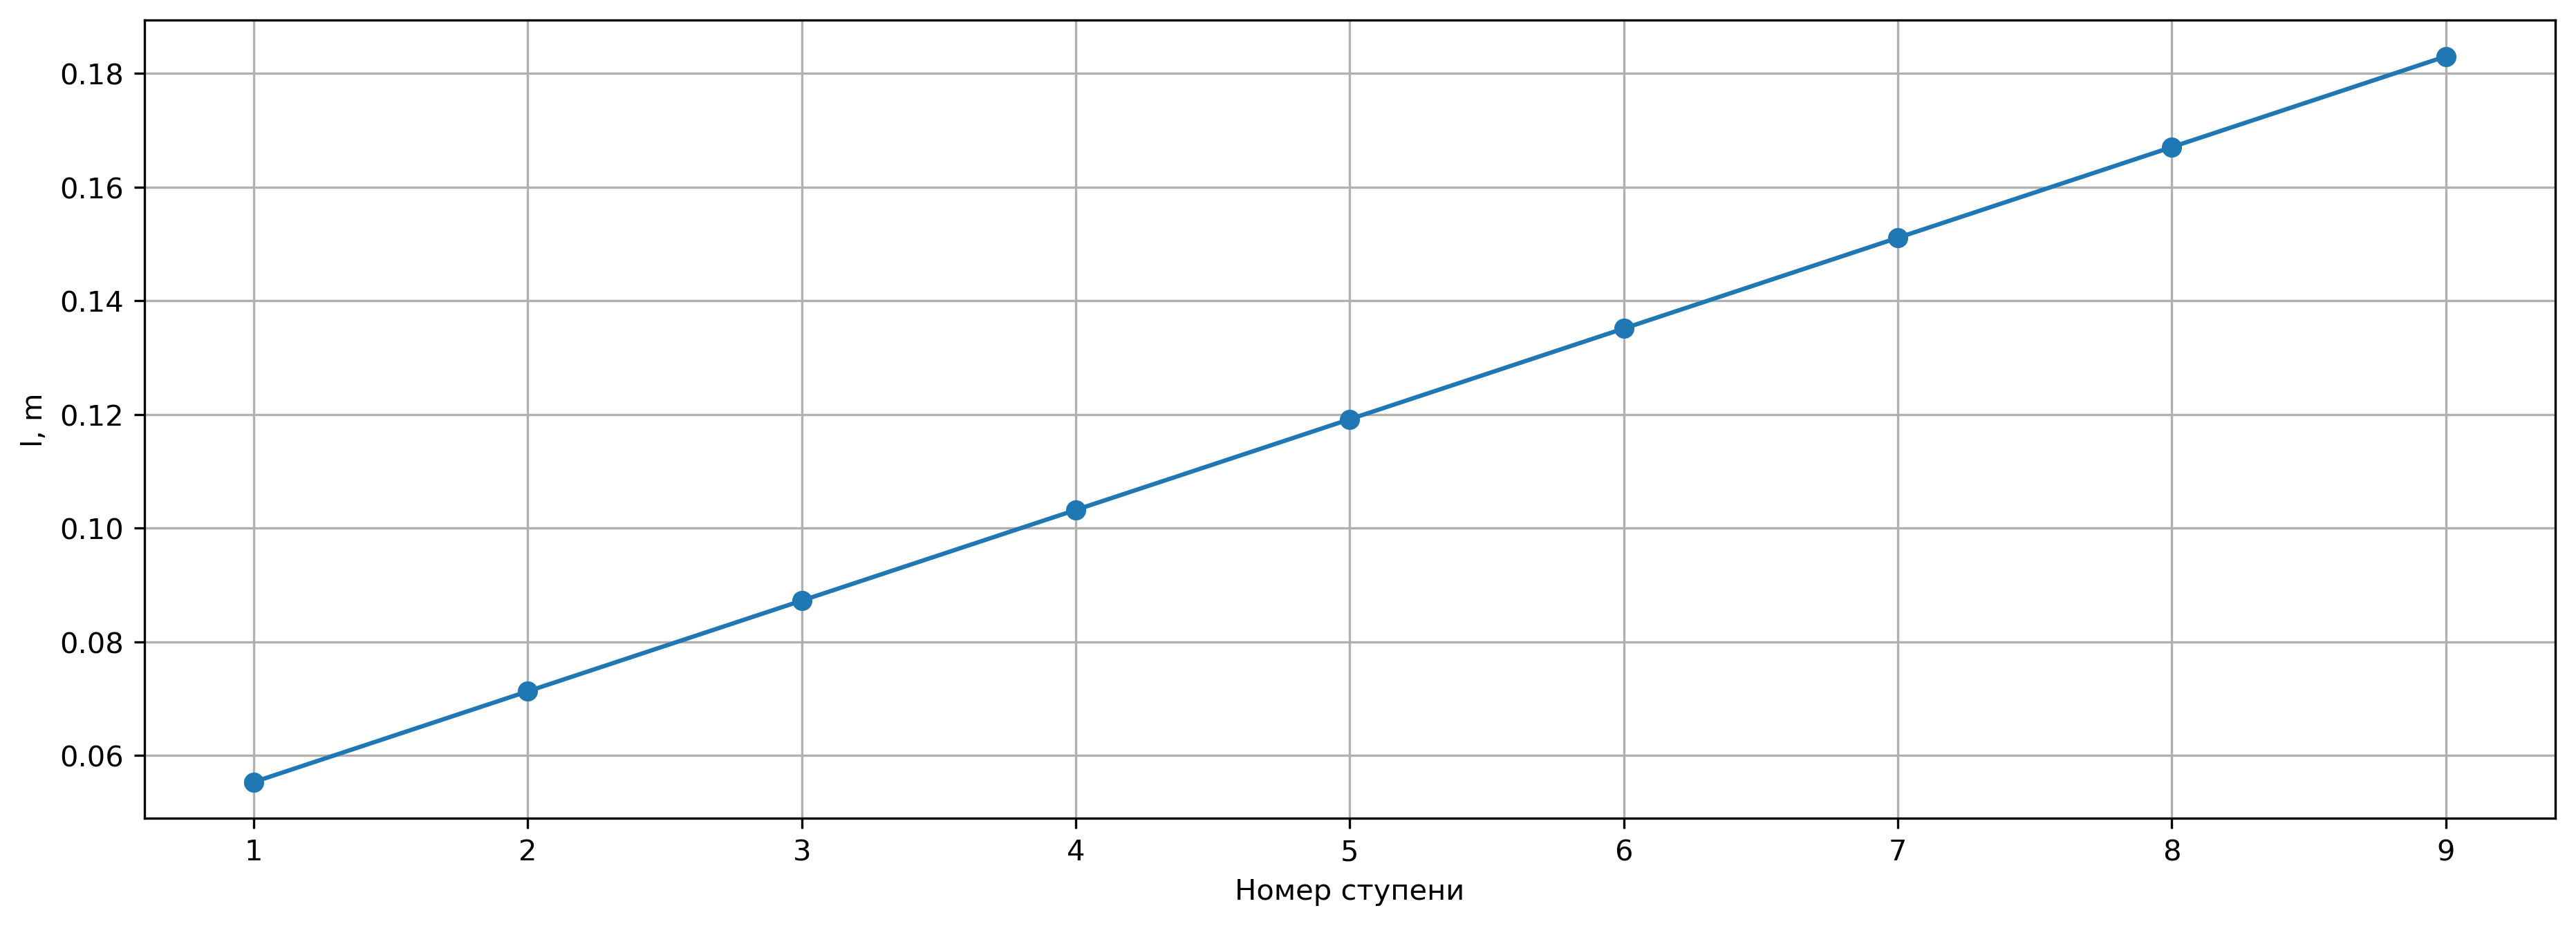

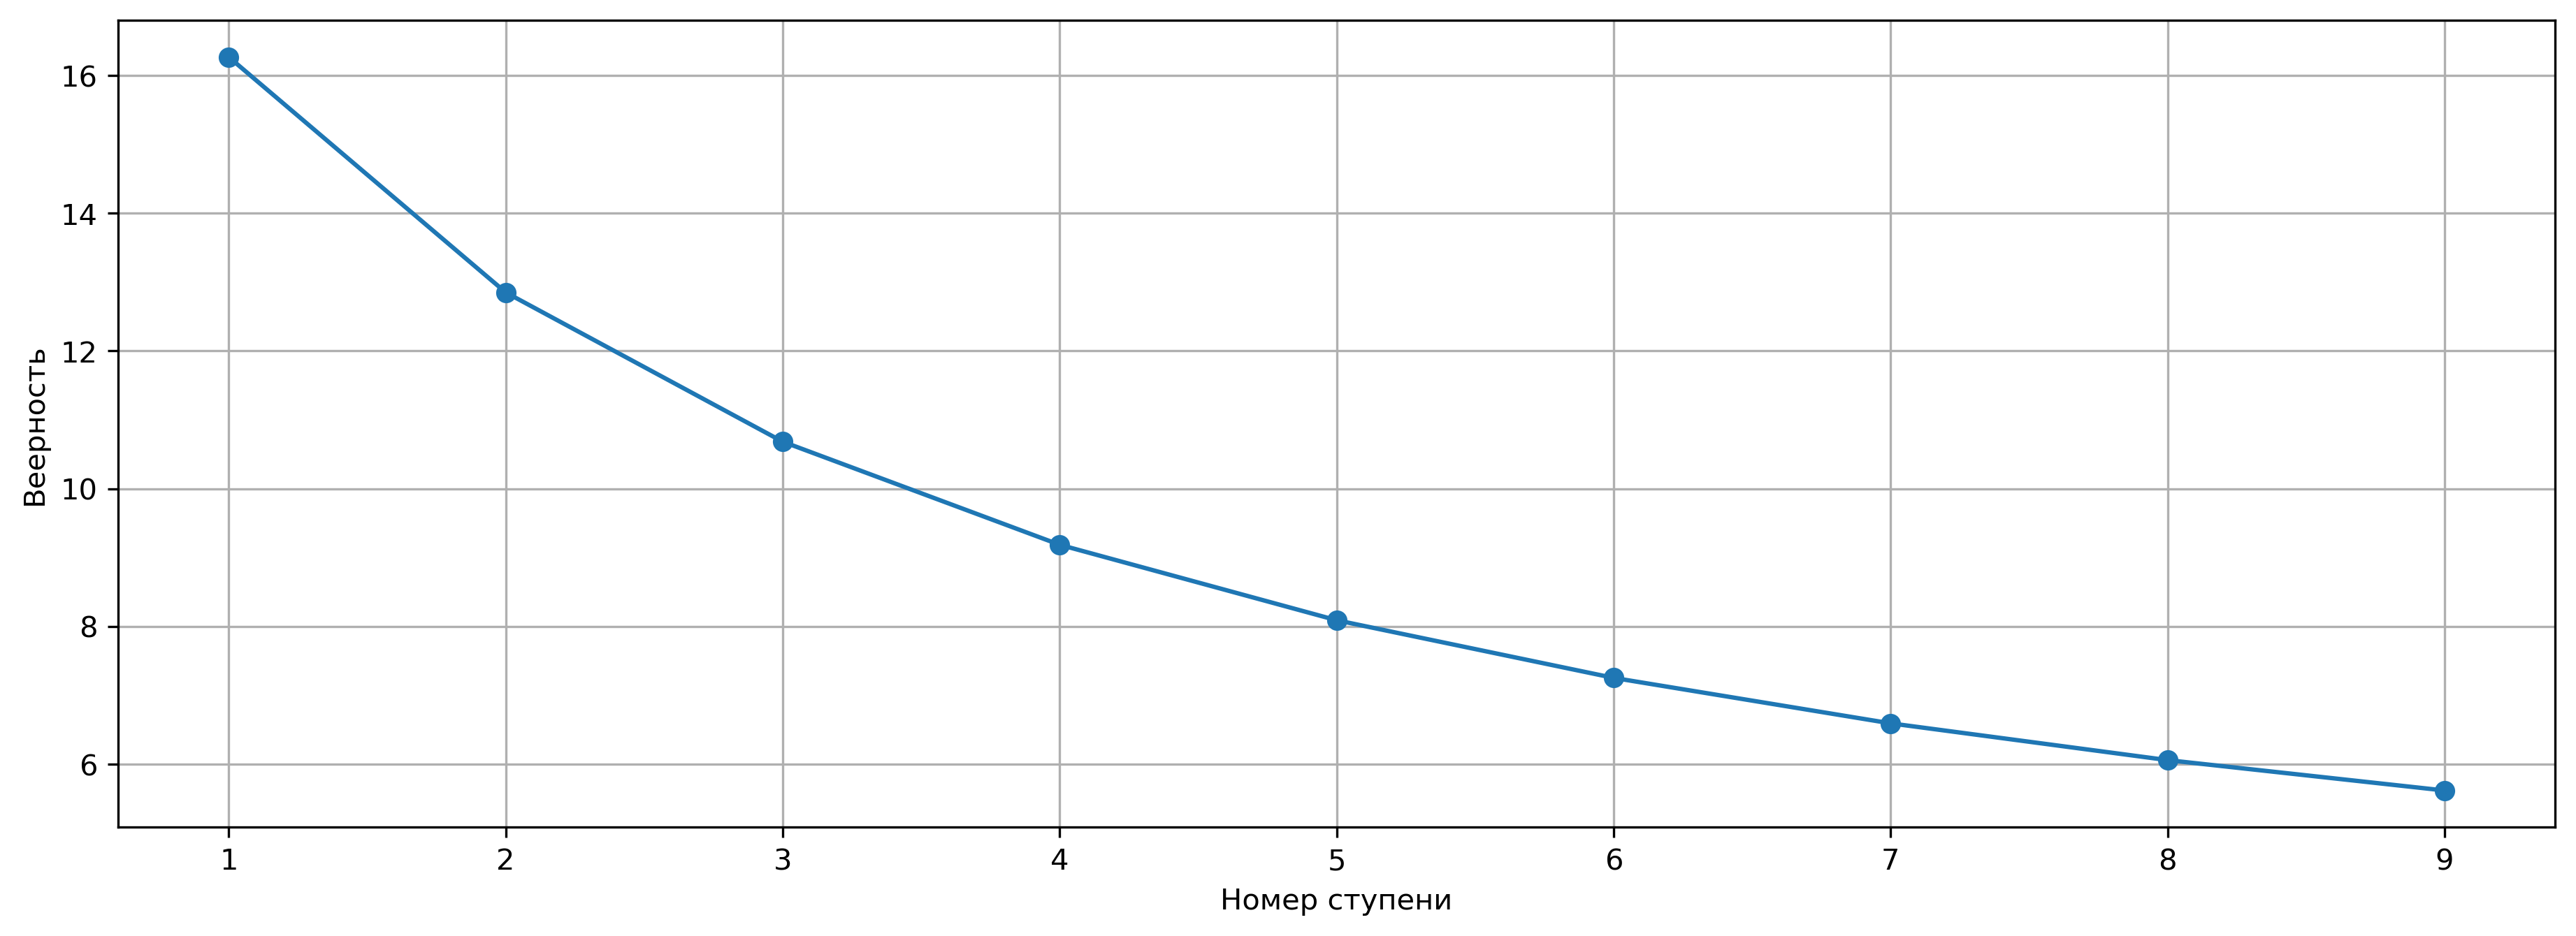

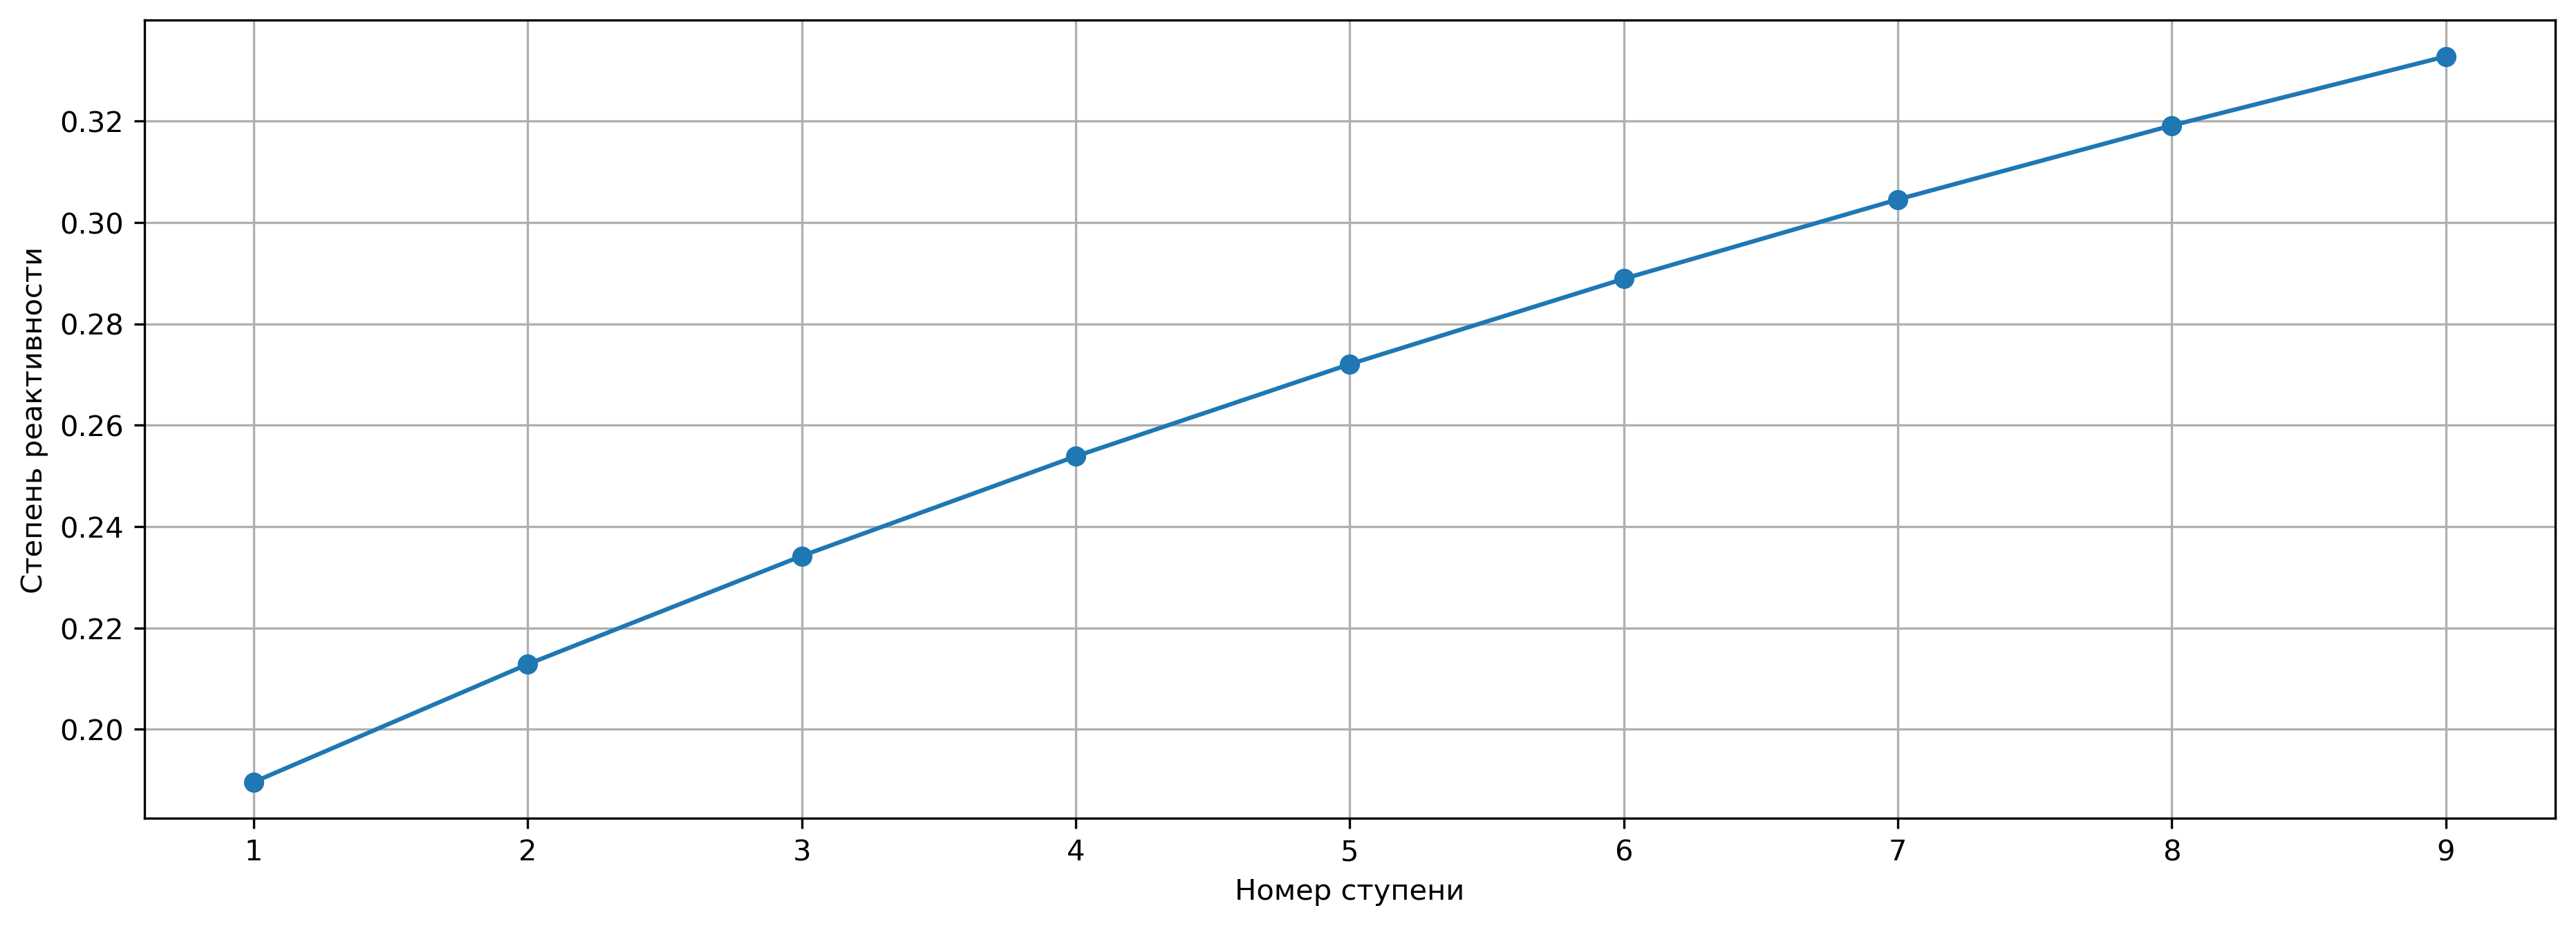

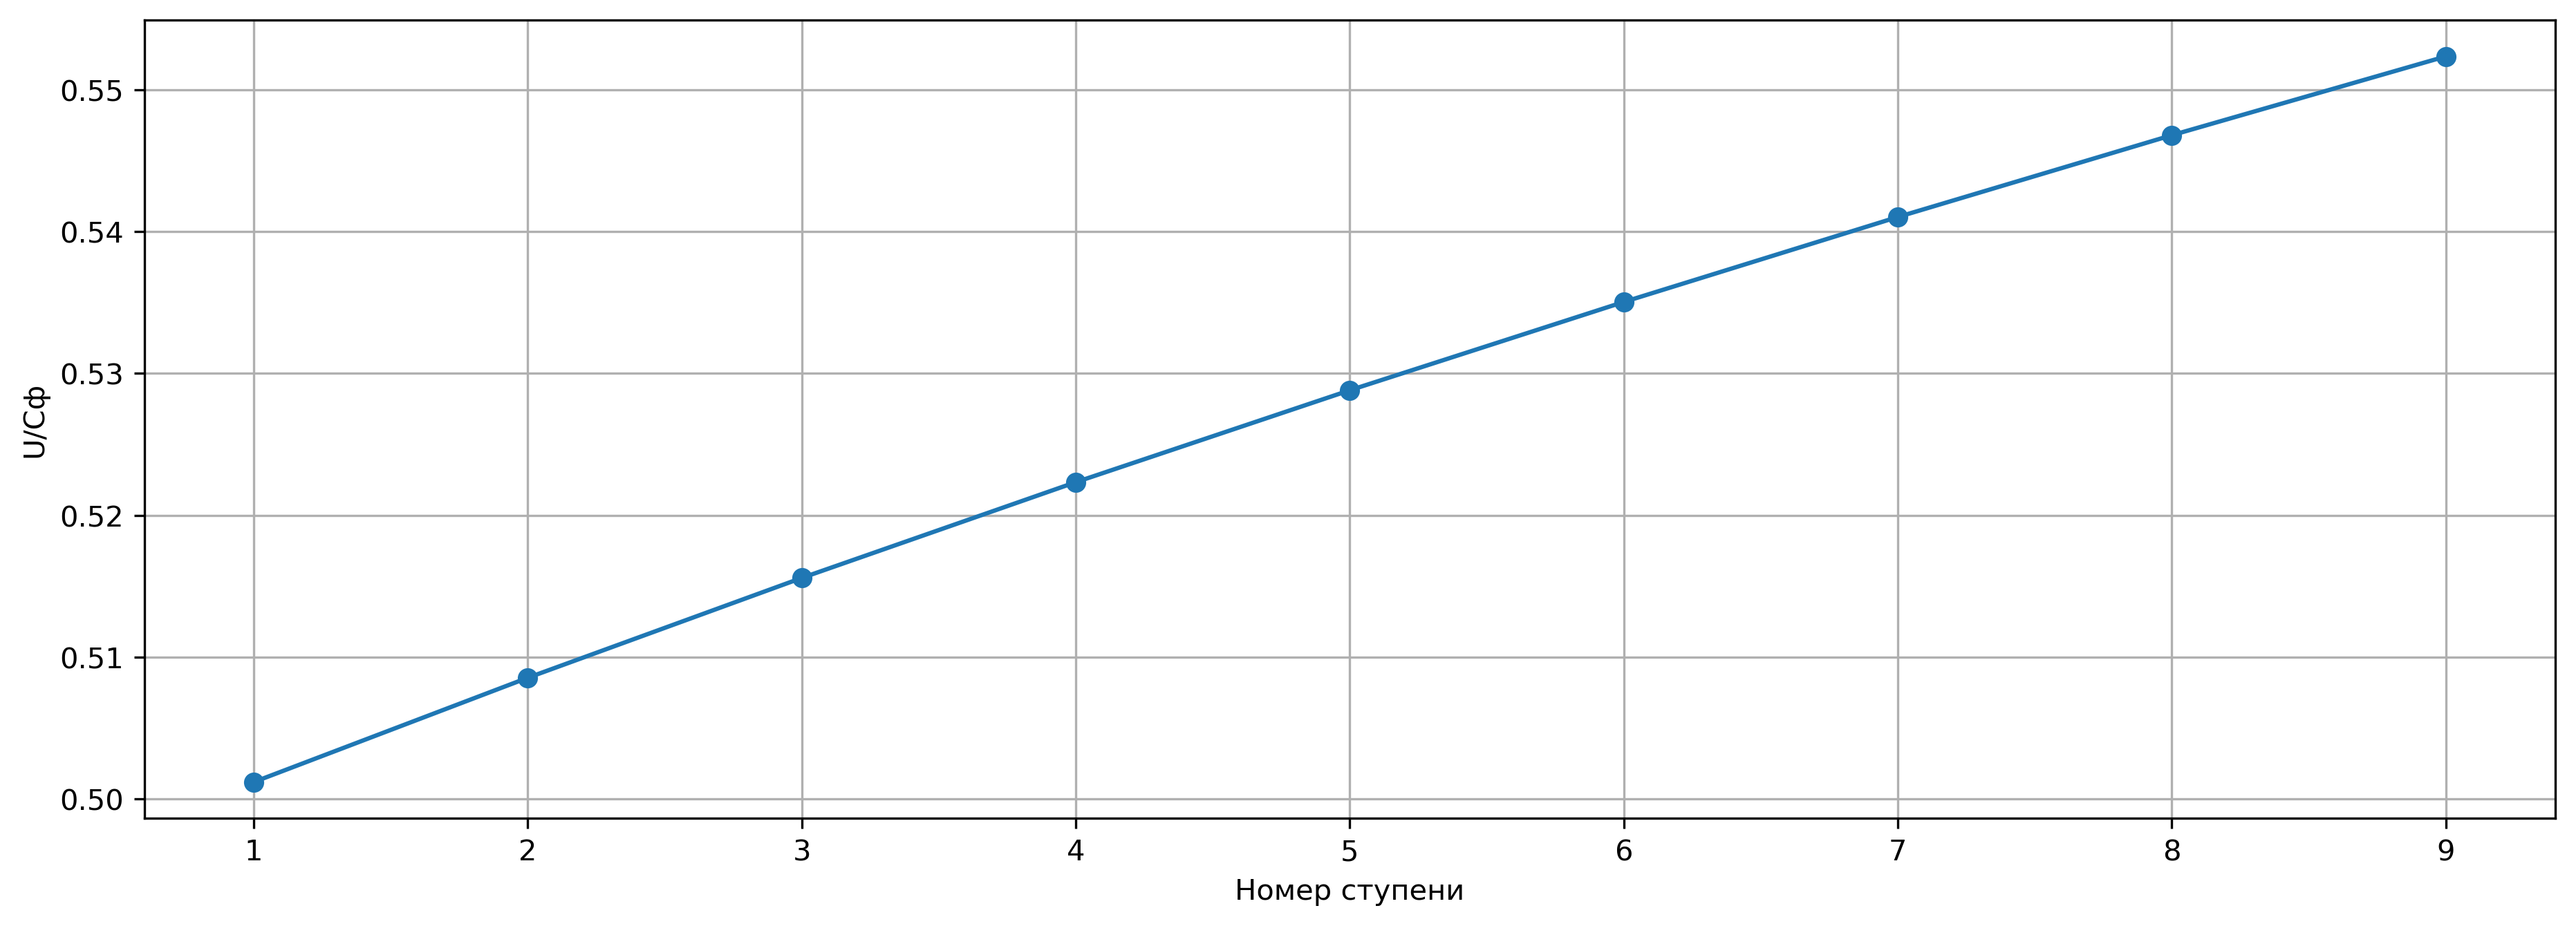

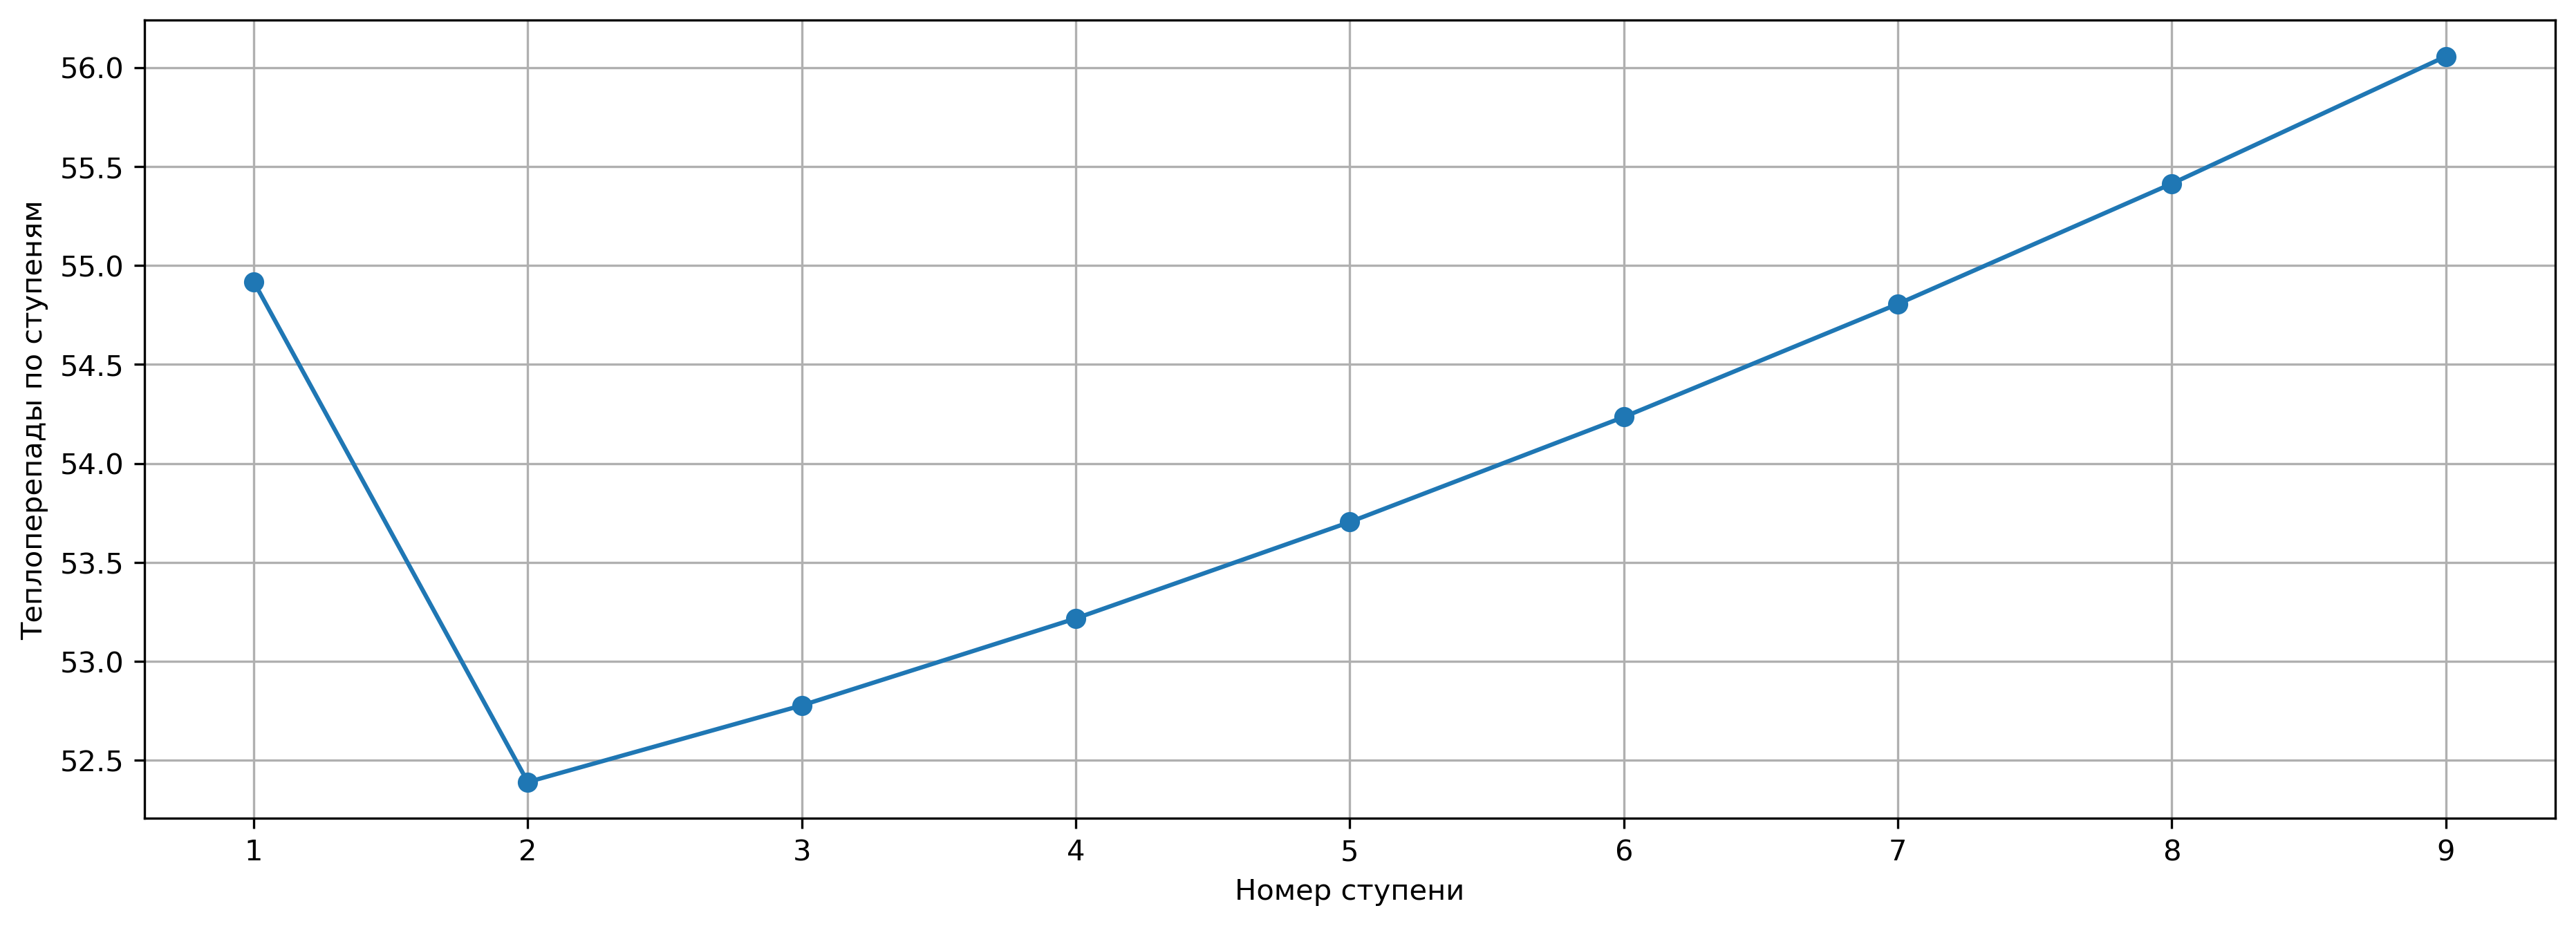

In [88]:
speed_stage_diam = d_opt
rotation_speed = n
n_stages = 9
mass_flow = 637
p0, h0, pz = B.get_point_z
p0 = p0 * MPa
pz = pz * MPa


# Techincal params
delta_diam = 0.2
speed_coefficient = 0.93
alpha_1 = 14
root_reaction_degree = 0.09
discharge_coefficient = 0.96
overlapping = 0.003
efficiency = 0.88
veernost_1 = 37
my_blade_No = 8
diameter_my, blade_length_my, veernost_my, reaction_degree_my, u_cf_my, new_actual_heat_drop_my, p_in, T_in, h_in = B.each_blade(speed_stage_diam, 
                                                                                                               rotation_speed, 
                                                                                                               n_stages, 
                                                                                                               mass_flow, p0, h0, 
                                                                                                               pz, delta_diam, 
                                                                                                               speed_coefficient, 
                                                                                                               alpha_1, 
                                                                                                               root_reaction_degree, 
                                                                                                               discharge_coefficient, 
                                                                                                               overlapping, 
                                                                                                               efficiency, 
                                                                                                               veernost_1, 
                                                                                                               my_blade_No)

## Расчёт ступени номер 8

Centrifugal stress: 95.36 MPa; Bending stress: 0.59 MPa; Final rotor height: 0.10 mm


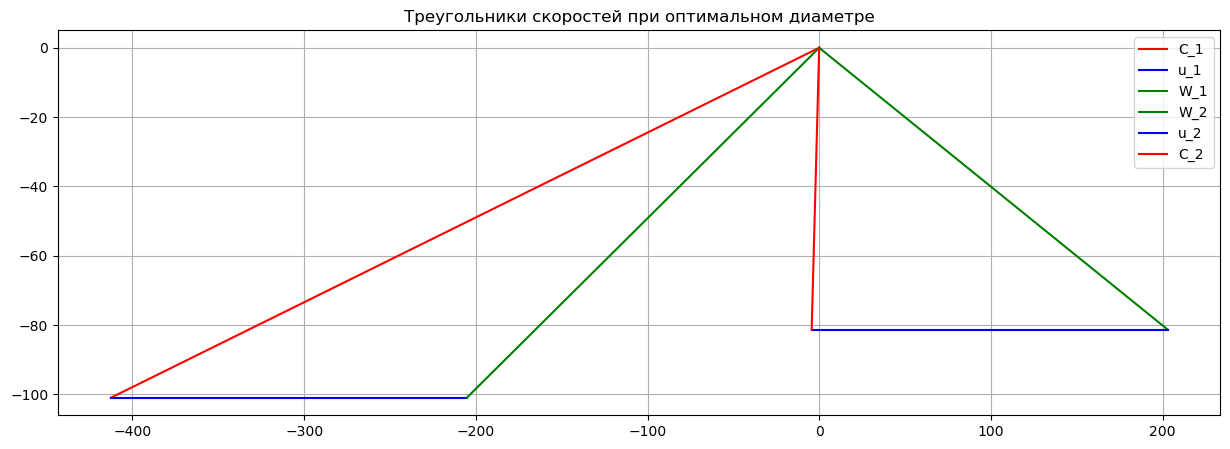

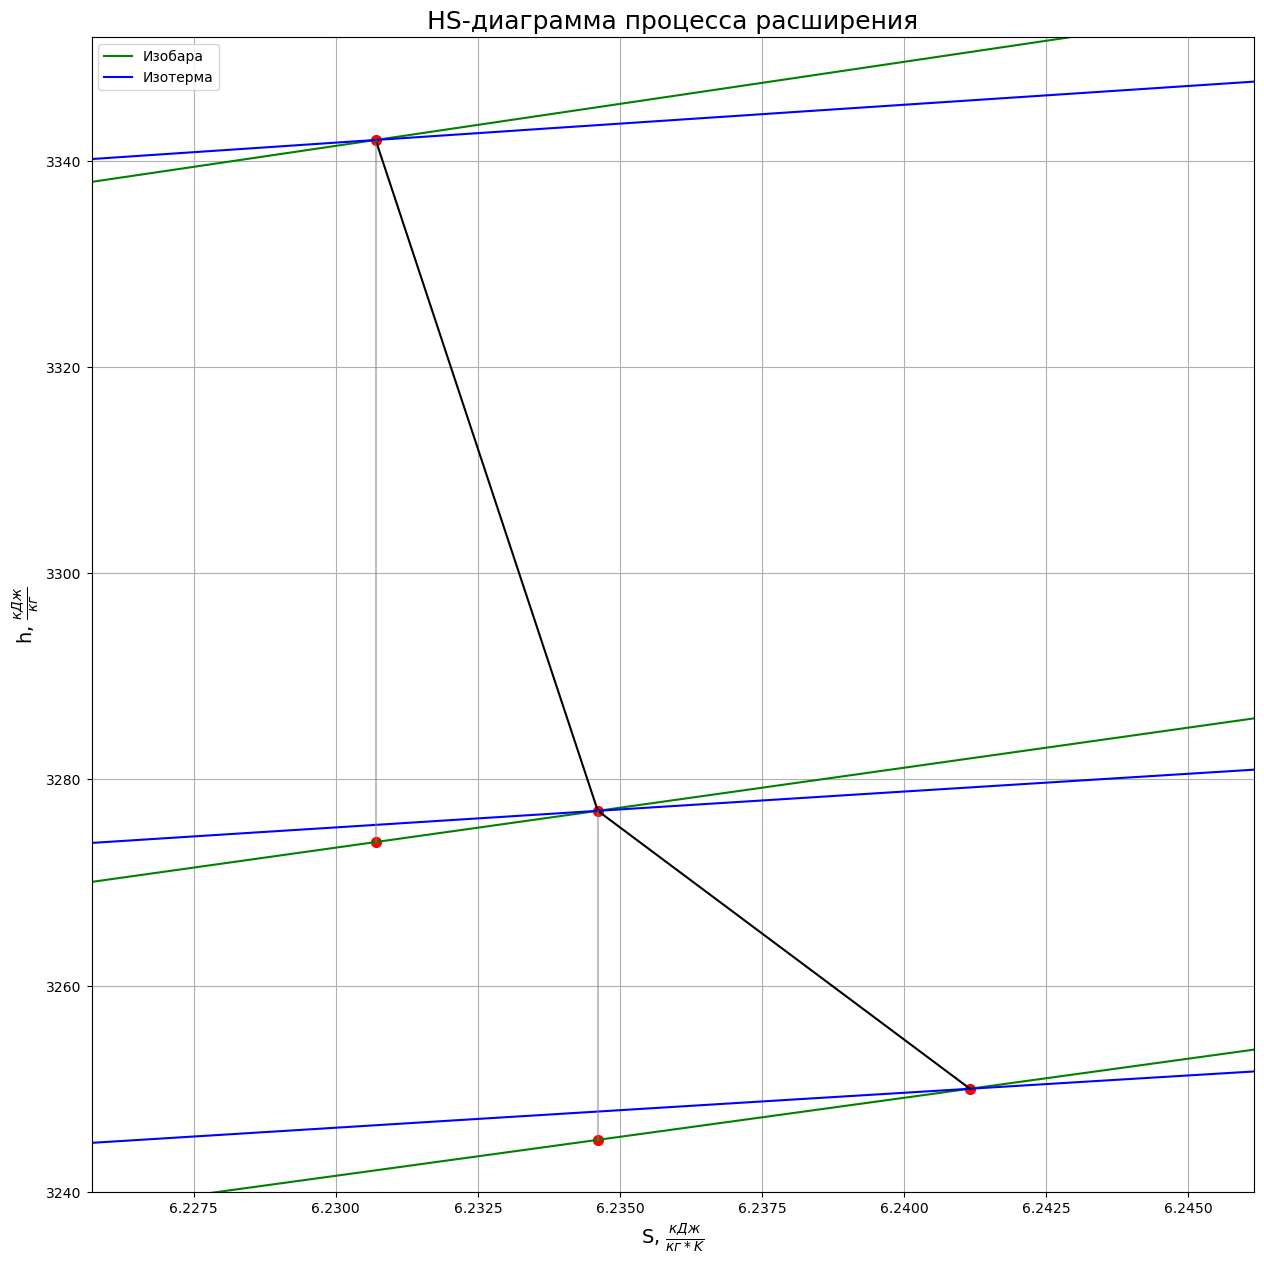

Внутренний КПД: 69.76%


In [91]:
H_o = 100
k = 1.33
n = 60
rho = reaction_degree_my
b_1 = 51.5/1000
d_r = diameter_my
p0 = p_in * MPa
t0 = T_in
alpha_1_e = 14
t_1opt = (0.7+0.87)/2
t_opt_2 = (0.60+0.70)/2
b_2 = 0.1
G = inlet_mass_flow
pere = 0.003
xi_vs = 1
W_min_atlas = 0.575

eff_oi = B.my_blade(H_o, p0,t0,
                                                                                               k, n, rho,
                                                                                               b_1, alpha_1_e,
                                                                                               t_1opt, t_opt_2, b_2,
                                                                                               G, pere, xi_vs, d_r,
                                                                                               W_min_atlas,
                                                                                               blade_length_my)[2]
print(f"Внутренний КПД: {eff_oi*100:.2f}%")

In [92]:
B  = cst(my_class, A, H_0, d_opt , n, b_1,t_1opt, alpha_1e, b_2, t_2opt)
sigma_isg, sigma_rast, b_2, l_2, z_2 = B.stress(0.1,51.5/1000,0.45 /10**6)
print("Прочностные и геометрические параметры:")
print(f"Напряжение на изгиб: {sigma_isg:.2f} МПа")#, , sigma_rast, b_2, l_2, z_2 
print(f"Напряжение на растяжение: {sigma_rast:.2f} МПа")
print(f"Хорда рабочей лопатки: {b_2*10**3:.2f} мм")
print(f"Высота рабочей лопатки: {l_2*10**3:.2f} мм")
print(f"Количество рабочих лопаток: {z_2}")

Прочностные и геометрические параметры:
Напряжение на изгиб: 16.41 МПа
Напряжение на растяжение: 2.07 МПа
Хорда рабочей лопатки: 90.57 мм
Высота рабочей лопатки: 26.51 мм
Количество рабочих лопаток: 44
